# DDPM Variant: SiLU Activation

This notebook is a Section 3 architectural variant of the baseline DDPM that replaces the baseline activation setup with SiLU while keeping the same overall diffusion workflow and experimental framing.


## Section 3: Denoising Diffusion Probabilistic Model (DDPM)

**Objective:** Implement a DDPM that generates handwritten digits by learning to reverse a gradual noising process.

**Key Components:**
- **Forward Process:** Add Gaussian noise to images over T=1000 steps (linear schedule β: 1e-4 → 0.02)
- **Reverse Process:** A lightweight U-Net predicts the added noise at each step, then iteratively denoises
- **Training:** MSE loss between predicted noise and actual noise

**Dataset:** MNIST (28×28 grayscale images)

## 1. Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Hyperparameters

In [2]:
# DDPM Hyperparameters (as specified in the assignment)
T           = 1000       # Total diffusion timesteps
BETA_START  = 1e-4       # Minimum noise level (β_1)
BETA_END    = 0.02       # Maximum noise level (β_T)
BATCH_SIZE  = 64
IMAGE_SIZE  = 28         # MNIST image size
CHANNELS    = 1          # Grayscale
LR          = 1e-3       # Learning rate
EPOCHS      = 10

DDPM_PATH   = 'models/ddpm_unet.pth'

print("DDPM Hyperparameters:")
print(f"  Timesteps (T)  : {T}")
print(f"  Beta schedule  : {BETA_START} → {BETA_END} (linear)")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Image Size     : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Learning Rate  : {LR}")
print(f"  Optimizer      : Adam")
print(f"  Loss           : MSE")
print(f"  Epochs         : {EPOCHS}")

DDPM Hyperparameters:
  Timesteps (T)  : 1000
  Beta schedule  : 0.0001 → 0.02 (linear)
  Batch Size     : 64
  Image Size     : 28x28
  Learning Rate  : 0.001
  Optimizer      : Adam
  Loss           : MSE
  Epochs         : 10


## 3. Load MNIST Dataset

100%|██████████| 9.91M/9.91M [00:04<00:00, 1.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 103kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 889kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]


Training images : 60000
Batches/epoch   : 938


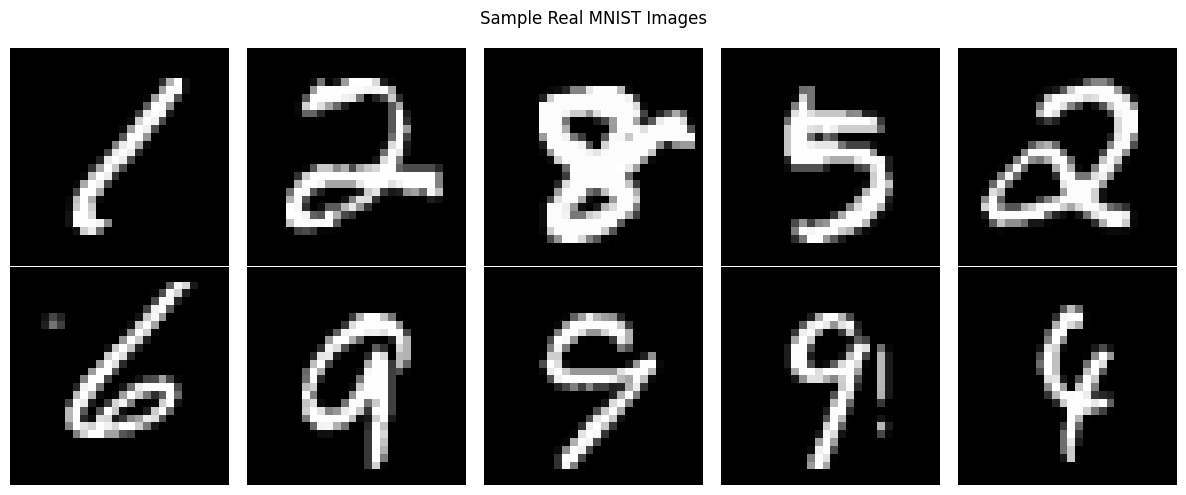

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # Scale to [-1, 1]
])

train_dataset = datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print(f"Training images : {len(train_dataset)}")
print(f"Batches/epoch   : {len(train_loader)}")

# Show sample real images
sample_imgs, _ = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Sample Real MNIST Images')
plt.tight_layout()
plt.show()

## 4. Forward Diffusion Process — Linear Noise Schedule

The forward process gradually adds Gaussian noise over T steps:

$$q(x_t \mid x_0) = \mathcal{N}\!\left(x_t;\; \sqrt{\bar{\alpha}_t}\, x_0,\; (1 - \bar{\alpha}_t)\,I\right)$$

So we can sample $x_t$ directly from $x_0$ and a noise $\varepsilon \sim \mathcal{N}(0, I)$:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon$$

where $\bar{\alpha}_t = \prod_{i=1}^{t} \alpha_i$ and $\alpha_t = 1 - \beta_t$.

In [4]:
class DiffusionSchedule:
    """
    Pre-computes all quantities needed for the forward and reverse processes.
    Linear beta schedule: beta_t increases from BETA_START to BETA_END over T steps.
    """
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T = T
        self.device = device

        # Linear noise schedule  β_1 ... β_T
        self.betas = torch.linspace(beta_start, beta_end, T).to(device)  # (T,)

        # α_t = 1 - β_t
        self.alphas = 1.0 - self.betas                                    # (T,)

        # ᾱ_t = Π_{i=1}^{t} α_i  (cumulative product)
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)           # (T,)

        # √ᾱ_t  and  √(1 - ᾱ_t)  — used in forward sampling
        self.sqrt_alphas_cumprod       = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        """
        Forward diffusion: sample x_t from x_0 at timestep t.
        x_t = √ᾱ_t * x_0 + √(1-ᾱ_t) * ε

        Args:
            x0   : clean images,  shape (B, C, H, W)
            t    : integer timestep indices, shape (B,)
            noise: optional pre-sampled noise; if None, sampled from N(0,I)
        Returns:
            x_t  : noisy images at timestep t
            noise: the Gaussian noise that was added
        """
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_ab   = self.sqrt_alphas_cumprod[t]            # (B,)
        sqrt_1mab = self.sqrt_one_minus_alphas_cumprod[t]  # (B,)

        # Reshape for broadcasting: (B,) -> (B, 1, 1, 1)
        sqrt_ab   = sqrt_ab.view(-1, 1, 1, 1)
        sqrt_1mab = sqrt_1mab.view(-1, 1, 1, 1)

        return sqrt_ab * x0 + sqrt_1mab * noise, noise


# Instantiate the schedule
schedule = DiffusionSchedule(T=T, beta_start=BETA_START, beta_end=BETA_END, device=device)

print(f"Beta range  : {schedule.betas[0].item():.5f} → {schedule.betas[-1].item():.5f}")
print(f"Alpha range : {schedule.alphas[0].item():.5f} → {schedule.alphas[-1].item():.5f}")
print(f"ᾱ range     : {schedule.alphas_cumprod[0].item():.5f} → {schedule.alphas_cumprod[-1].item():.6f}")

Beta range  : 0.00010 → 0.02000
Alpha range : 0.99990 → 0.98000
ᾱ range     : 0.99990 → 0.000040


## 5. Visualise the Forward Noising Process
Show how a clean image gradually becomes pure noise as t increases from 0 to T.

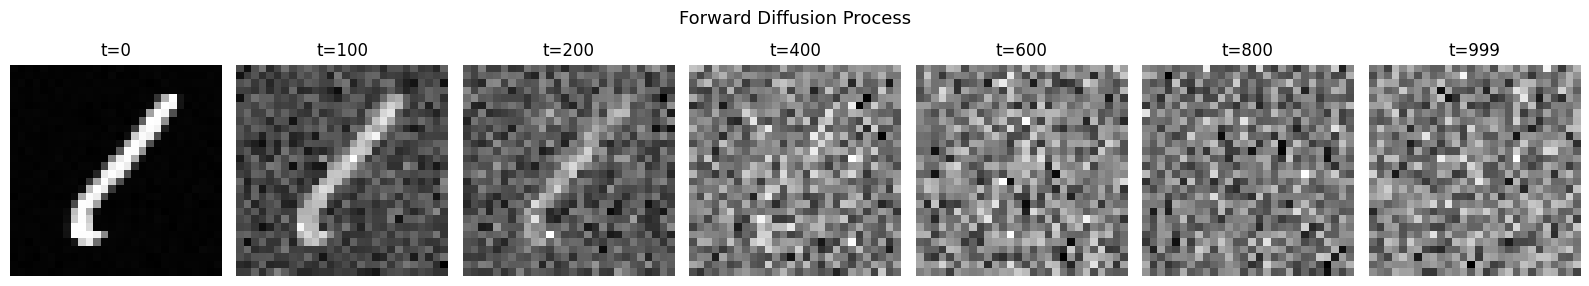

In [5]:
def show_noising_process(schedule, image, steps=None, title="Forward Diffusion Process"):
    """Display a single image at several noise levels t."""
    if steps is None:
        steps = [0, 100, 200, 400, 600, 800, 999]

    fig, axes = plt.subplots(1, len(steps), figsize=(16, 3))
    x0 = image.unsqueeze(0).to(device)   # (1, 1, 28, 28)

    for ax, t in zip(axes, steps):
        t_tensor = torch.tensor([t], device=device)
        xt, _ = schedule.q_sample(x0, t_tensor)
        img = xt.squeeze().cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f't={t}')
        ax.axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# Pick one sample and visualise
clean_img = sample_imgs[0]  # (1, 28, 28)
show_noising_process(schedule, clean_img)

## 6. U-Net Architecture for Noise Prediction

The model takes a **noisy image** as input and predicts the noise $\varepsilon$ added at timestep $t$.  
Two key improvements make the outputs sharp:

1. **Sinusoidal time embedding** — $t$ is encoded into 128 features via $\sin/\cos$ at log-spaced frequencies (like Transformer positional encoding) and **added** as a bias to every feature map.
2. **Skip connections** — encoder feature maps are **concatenated** into the decoder at matching spatial resolutions, so fine detail lost during downsampling is restored on the way back up.

```
Time   : t → SinusoidalEmb(128) → Linear → SiLU → temb (128-d)

Encoder:  Conv(1→32,  s=2)+GN  → e1 (B, 32, 14,14)  + time_proj ──────────┐
          Conv(32→64, s=2)+GN  → e2 (B, 64,  7, 7)  + time_proj ────────┐ │
          Conv(64→128,s=2)+GN  → e3 (B,128,  4, 4)  + time_proj         │ │
Middle :  Conv(128→128   )+GN  →  m (B,128,  4, 4)  + time_proj         │ │
                                                                          │ │
Decoder:  ConvT(128→64, 4→7)   → cat(e2, 64-ch→128) → Conv(128→64)+GN ←┘ │
          ConvT(64→32,  7→14)  → cat(e1, 32-ch→ 64) → Conv( 64→32)+GN ←──┘
          ConvT(32→1,  14→28)  → (B, 1, 28, 28)  ← predicted noise
```

> **Skip pairings (spatial sizes must match!):**  
> `e2` (7×7) → skipped into decoder after 1st upsample (4→7)  
> `e1` (14×14) → skipped into decoder after 2nd upsample (7→14)

In [ ]:
import math


class SinusoidalTimeEmbedding(nn.Module):
    """
    Sinusoidal positional encoding for diffusion timesteps.

    For timestep t, produces a (dim,) vector:
        emb[i]          = sin(t / 10000^(2i/dim))   for i < dim//2
        emb[dim//2 + i] = cos(t / 10000^(2i/dim))   for i < dim//2

    Gives the network 'dim' distinct, smoothly-varying features per timestep —
    much richer than a single normalised scalar t/T.
    """

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device   = t.device
        half_dim = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device) / (half_dim - 1)
        )
        angles = t[:, None].float() * freqs[None, :]           # (B, half_dim)
        emb    = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (B, dim)
        return emb


class UNet(nn.Module):
    """
    U-Net with sinusoidal time conditioning and skip connections.

    Input  : noisy image (1-ch)  → (B, 1, 28, 28)
    Time   : SinusoidalEmbedding(128) → Linear → SiLU → 128-d bias added at each level
    Output : predicted noise     → (B, 1, 28, 28)

    Encoder : Conv(1→32,  s=2)+GN → e1 (B, 32, 14, 14)   ← skip to dec stage 2
              Conv(32→64, s=2)+GN → e2 (B, 64,  7,  7)   ← skip to dec stage 1
              Conv(64→128,s=2)+GN → e3 (B, 128, 4,  4)
    Middle  : Conv(128→128)+GN    → m  (B, 128, 4,  4)

    Decoder : ConvT(128→64, 4→7)  → cat(e2: 64-ch) → 128-ch → Conv(128→64)+GN  [7×7]
              ConvT(64→32,  7→14) → cat(e1: 32-ch) → 64-ch  → Conv(64→32)+GN  [14×14]
              ConvT(32→1,  14→28)                                               [28×28]

    Skip connections pair encoder and decoder at matching spatial resolutions:
        e2 (7x7)  → decoder after 1st upsample (4→7)
        e1 (14x14)→ decoder after 2nd upsample (7→14)
    """

    def __init__(self, in_channels=1, time_emb_dim=128):
        super(UNet, self).__init__()

        # ── Sinusoidal time embedding ───────────────────────────────────────
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
        )#convrt timestep t into vector so model can understand this img is at timestamp t

        # Per-level time projections (bias added after GroupNorm)
        self.time_proj_e1  = nn.Linear(time_emb_dim, 32)
        self.time_proj_e2  = nn.Linear(time_emb_dim, 64)
        self.time_proj_e3  = nn.Linear(time_emb_dim, 128)
        self.time_proj_m   = nn.Linear(time_emb_dim, 128)
        self.time_proj_d1  = nn.Linear(time_emb_dim, 64)
        self.time_proj_d2  = nn.Linear(time_emb_dim, 32)

        # ── Encoder ────────────────────────────────────────────────────────
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
        )  # → (B, 32, 14, 14)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
        )  # → (B, 64, 7, 7)

        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
        )  # → (B, 128, 4, 4)

        # ── Middle block ───────────────────────────────────────────────────
        self.middle = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
        )  # → (B, 128, 4, 4)

        # ── Decoder ────────────────────────────────────────────────────────
        # Stage 1:  4 → 7,  skip from e2 (64-ch, same 7×7 spatial size)
        self.dec1_up   = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1)
        # after cat with e2: 64 + 64 = 128 channels
        self.dec1_conv = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
        )  # → (B, 64, 7, 7)

        # Stage 2:  7 → 14,  skip from e1 (32-ch, same 14×14 spatial size)
        self.dec2_up   = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        # after cat with e1: 32 + 32 = 64 channels
        self.dec2_conv = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
        )  # → (B, 32, 14, 14)

        # Stage 3:  14 → 28,  no skip
        self.dec3 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)
        # → (B, 1, 28, 28)  — raw noise prediction, no activation

    def forward(self, x, t):
        """
        Args:
            x : noisy image, shape (B, 1, 28, 28)
            t : integer timestep indices, shape (B,)
        Returns:
            Predicted noise, shape (B, 1, 28, 28)
        """
        # ── Sinusoidal time embedding ───────────────────────────────────────
        temb = self.time_mlp(t)   # (B, 128)

        # ── Encoder ────────────────────────────────────────────────────────
        e1 = self.enc1(x)                                        # (B, 32, 14, 14)
        e1 = e1 + self.time_proj_e1(temb).view(-1, 32, 1, 1)

        e2 = self.enc2(e1)                                       # (B, 64, 7, 7)
        e2 = e2 + self.time_proj_e2(temb).view(-1, 64, 1, 1)

        e3 = self.enc3(e2)                                       # (B, 128, 4, 4)
        e3 = e3 + self.time_proj_e3(temb).view(-1, 128, 1, 1)

        # ── Middle ─────────────────────────────────────────────────────────
        m  = self.middle(e3)                                     # (B, 128, 4, 4)
        m  = m + self.time_proj_m(temb).view(-1, 128, 1, 1)

        # ── Decoder with skip connections ──────────────────────────────────
        # Stage 1: upsample 4→7, then cat with e2 (7×7) ← matched spatial size
        d1 = self.dec1_up(m)                                     # (B, 64,  7,  7)
        d1 = torch.cat([d1, e2], dim=1)                          # (B, 128, 7,  7)
        d1 = self.dec1_conv(d1)                                  # (B, 64,  7,  7)
        d1 = d1 + self.time_proj_d1(temb).view(-1, 64, 1, 1)

        # Stage 2: upsample 7→14, then cat with e1 (14×14) ← matched spatial size
        d2 = self.dec2_up(d1)                                    # (B, 32, 14, 14)
        d2 = torch.cat([d2, e1], dim=1)                          # (B, 64, 14, 14)
        d2 = self.dec2_conv(d2)                                  # (B, 32, 14, 14)
        d2 = d2 + self.time_proj_d2(temb).view(-1, 32, 1, 1)

        # Stage 3: upsample 14→28, final noise prediction
        d3 = self.dec3(d2)                                       # (B, 1, 28, 28)
        return d3


# Sanity check
test_model = UNet().to(device)
test_x = torch.randn(4, 1, 28, 28).to(device)
test_t = torch.randint(0, T, (4,)).to(device)
test_out = test_model(test_x, test_t)
print(f"U-Net input  shape : {test_x.shape}")
print(f"U-Net output shape : {test_out.shape}")
print(f"U-Net parameters   : {sum(p.numel() for p in test_model.parameters()):,}")
del test_model, test_x, test_t, test_out

U-Net input  shape : torch.Size([4, 1, 28, 28])
U-Net output shape : torch.Size([4, 1, 28, 28])
U-Net parameters   : 514,817


## 7. Training Setup

In [7]:
unet = UNet(in_channels=1).to(device)
optimizer = optim.Adam(unet.parameters(), lr=LR)
mse_loss  = nn.MSELoss()

ddpm_trained  = False
train_losses  = []

if os.path.exists(DDPM_PATH):
    os.makedirs('models', exist_ok=True)
    ckpt = torch.load(DDPM_PATH, map_location=device)
    unet.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    train_losses = ckpt.get('train_losses', [])
    ddpm_trained = True
    print(f"Loaded DDPM U-Net from '{DDPM_PATH}' (epoch {ckpt.get('epoch','?')})")
else:
    print(f"DDPM U-Net initialised — will train for {EPOCHS} epochs.")

print(f"Parameters : {sum(p.numel() for p in unet.parameters()):,}")

DDPM U-Net initialised — will train for 10 epochs.
Parameters : 514,817


## 8. DDPM Training Loop

**Algorithm (per batch):**
1. Sample clean images $x_0$ from MNIST
2. Sample random timesteps $t \sim \mathcal{U}\{1, T\}$ for each image
3. Sample Gaussian noise $\varepsilon \sim \mathcal{N}(0, I)$
4. Compute noisy image: $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \varepsilon$
5. Predict noise: $\hat{\varepsilon} = \text{UNet}(x_t, t)$
6. Loss: $\mathcal{L} = \|\varepsilon - \hat{\varepsilon}\|^2$

In [8]:
if ddpm_trained:
    print("Skipping training — model loaded from checkpoint.")
else:
    print("Starting DDPM training...\n")
    os.makedirs('models', exist_ok=True)
    unet.train()

    for epoch in range(EPOCHS):
        epoch_loss = 0.0

        for batch_idx, (x0, _) in enumerate(train_loader):
            x0 = x0.to(device)                              # (B, 1, 28, 28)
            B  = x0.size(0)

            # Sample random timesteps for each image in the batch
            t = torch.randint(0, T, (B,), device=device)    # (B,)

            # Forward diffusion: get noisy image and the actual noise
            x_t, noise = schedule.q_sample(x0, t)           # both (B, 1, 28, 28)

            # Predict noise
            predicted_noise = unet(x_t, t)                  # (B, 1, 28, 28)

            # MSE loss between predicted and actual noise
            loss = mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}] | MSE Loss: {avg_loss:.6f}")

    print("\nDDPM training completed!")

    # Save model
    torch.save({
        'epoch'              : EPOCHS,
        'model_state_dict'   : unet.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss'               : train_losses[-1],
        'train_losses'       : train_losses,
    }, DDPM_PATH)
    print(f"Model saved → '{DDPM_PATH}'")

Starting DDPM training...



KeyboardInterrupt: 

## 9. Plot Training Loss Curve

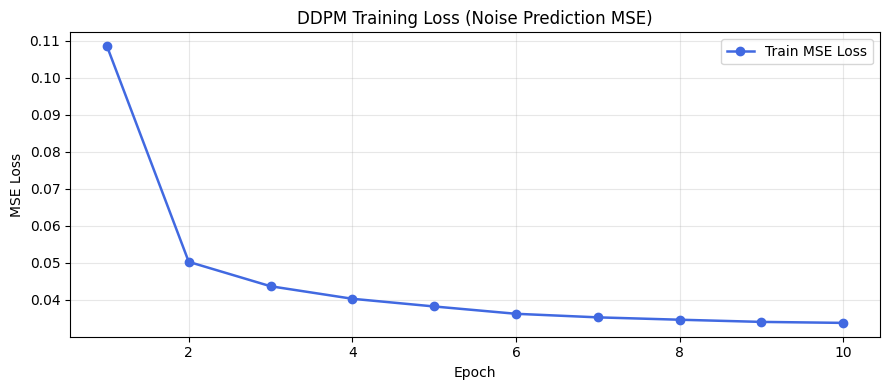

In [ ]:
if train_losses:
    plt.figure(figsize=(9, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses,
             marker='o', linewidth=1.8, color='royalblue', label='Train MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('DDPM Training Loss (Noise Prediction MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No loss data available — run the training cell first.")

## 10. Reverse Process — Image Sampling (Denoising)

Starting from pure Gaussian noise $x_T \sim \mathcal{N}(0, I)$, we iteratively apply the reverse step:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\hat{\varepsilon}_\theta(x_t, t)\right) + \sigma_t\,z$$

where $z \sim \mathcal{N}(0, I)$ for $t > 1$ and $z = 0$ for $t = 1$, and $\sigma_t = \sqrt{\beta_t}$.

In [ ]:
@torch.no_grad()
def p_sample(model, x_t, t_idx):
    """
    One reverse diffusion step: compute x_{t-1} from x_t.

    Args:
        model : trained U-Net
        x_t   : current noisy images, shape (B, 1, H, W)
        t_idx : integer timestep (same for all images in the batch)
    Returns:
        x_{t-1}: slightly denoised images
    """
    B = x_t.size(0)
    t_tensor = torch.full((B,), t_idx, device=device, dtype=torch.long)

    # Retrieve schedule values for this t
    beta_t       = schedule.betas[t_idx]
    alpha_t      = schedule.alphas[t_idx]
    alpha_bar_t  = schedule.alphas_cumprod[t_idx]

    # Predict noise
    eps_pred = model(x_t, t_tensor)

    # Compute the mean of p(x_{t-1} | x_t)
    coeff = beta_t / torch.sqrt(1.0 - alpha_bar_t)
    mean  = (1.0 / torch.sqrt(alpha_t)) * (x_t - coeff * eps_pred)

    if t_idx == 0:
        return mean   # Last step: no additional noise

    # Add noise scaled by σ_t = √β_t
    sigma_t = torch.sqrt(beta_t)
    z       = torch.randn_like(x_t)
    return mean + sigma_t * z


@torch.no_grad()
def sample_images(model, n_samples=16, show_progress_at=None):
    """
    Full reverse diffusion: start from x_T ~ N(0,I) and iterate down to x_0.

    Args:
        model           : trained U-Net
        n_samples       : number of images to generate
        show_progress_at: list of t values to display intermediate results
    Returns:
        x_0: generated images, shape (n_samples, 1, 28, 28)
    """
    model.eval()
    x = torch.randn(n_samples, 1, IMAGE_SIZE, IMAGE_SIZE, device=device)

    if show_progress_at:
        snapshots = {}

    for t in reversed(range(T)):                 # T-1 ... 0
        x = p_sample(model, x, t)
        if show_progress_at and t in show_progress_at:
            snapshots[t] = x.clone()

    if show_progress_at:
        return x, snapshots
    return x


print("Sampling function defined — will run after we confirm the model is ready.")

Sampling function defined — will run after we confirm the model is ready.


## 11. Visualise the Reverse Denoising Process
Show intermediate snapshots as the model iteratively denoises pure noise → digit.

Running full reverse diffusion (T=1000 steps) — this may take a minute...


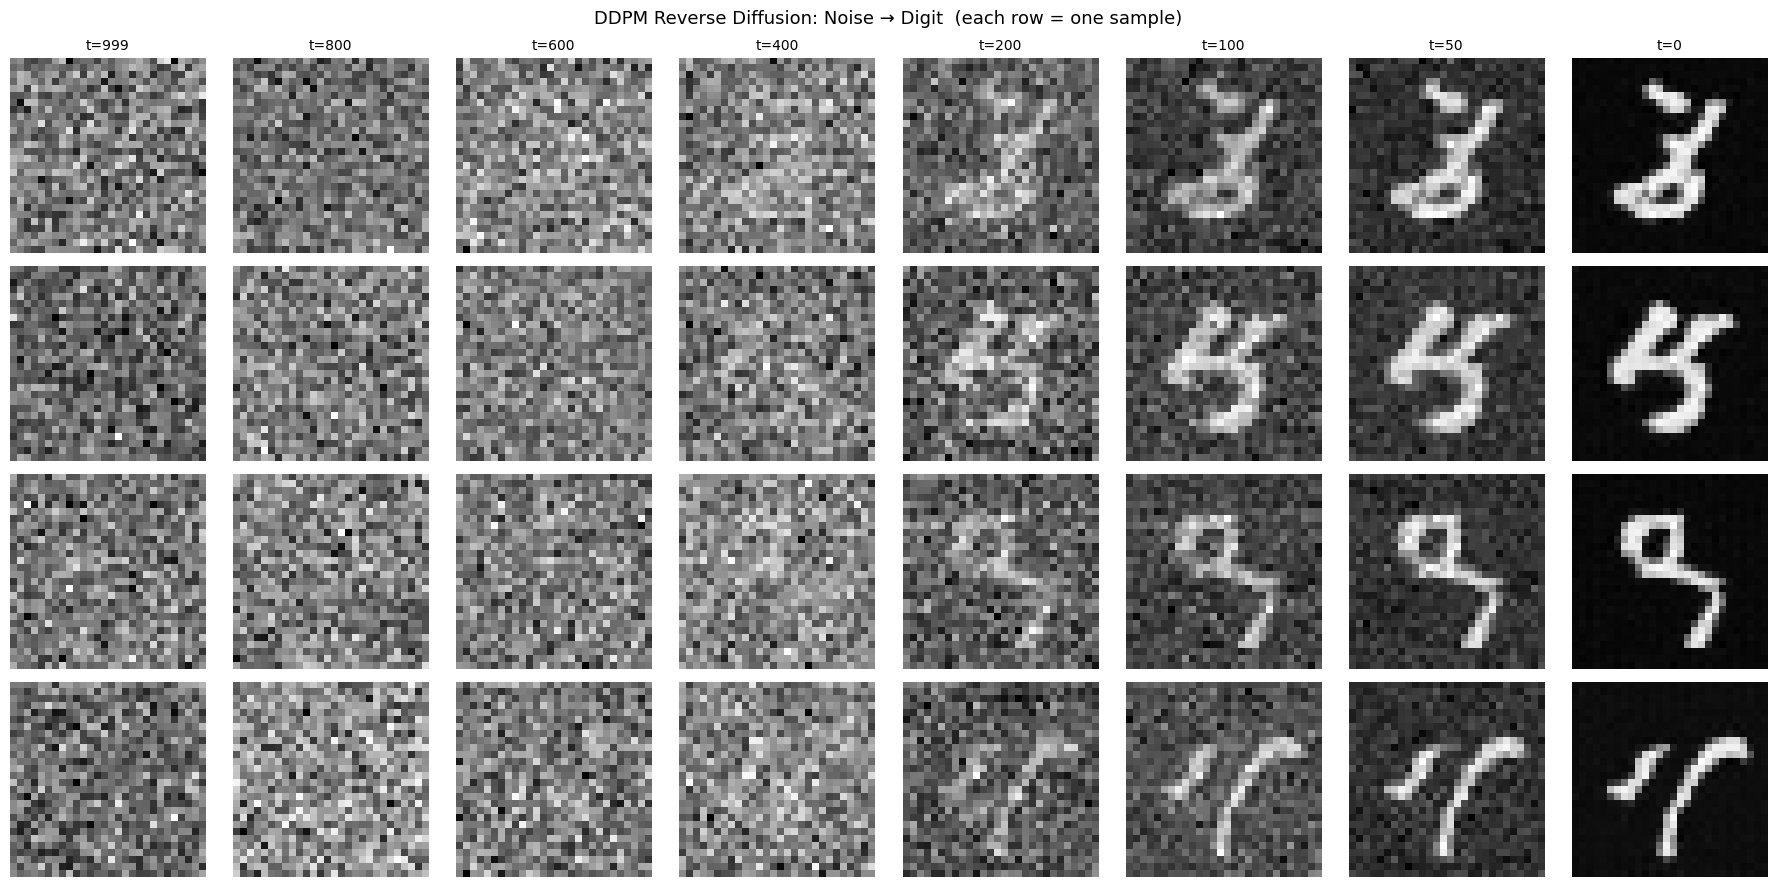

In [ ]:
# Show the denoising trajectory for a few images
PROGRESS_STEPS = [999, 800, 600, 400, 200, 100, 50, 0]

print("Running full reverse diffusion (T=1000 steps) — this may take a minute...")
final_imgs, snapshots = sample_images(unet, n_samples=4, show_progress_at=set(PROGRESS_STEPS))

fig, axes = plt.subplots(4, len(PROGRESS_STEPS), figsize=(18, 9))
for row in range(4):
    for col, t_val in enumerate(PROGRESS_STEPS):
        if t_val in snapshots:
            img = snapshots[t_val][row].squeeze().cpu().numpy()
        else:
            img = final_imgs[row].squeeze().cpu().numpy()
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't={t_val}', fontsize=10)

plt.suptitle('DDPM Reverse Diffusion: Noise → Digit  (each row = one sample)', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Generate Final Images (x_0)

Generating 16 final images from pure noise...


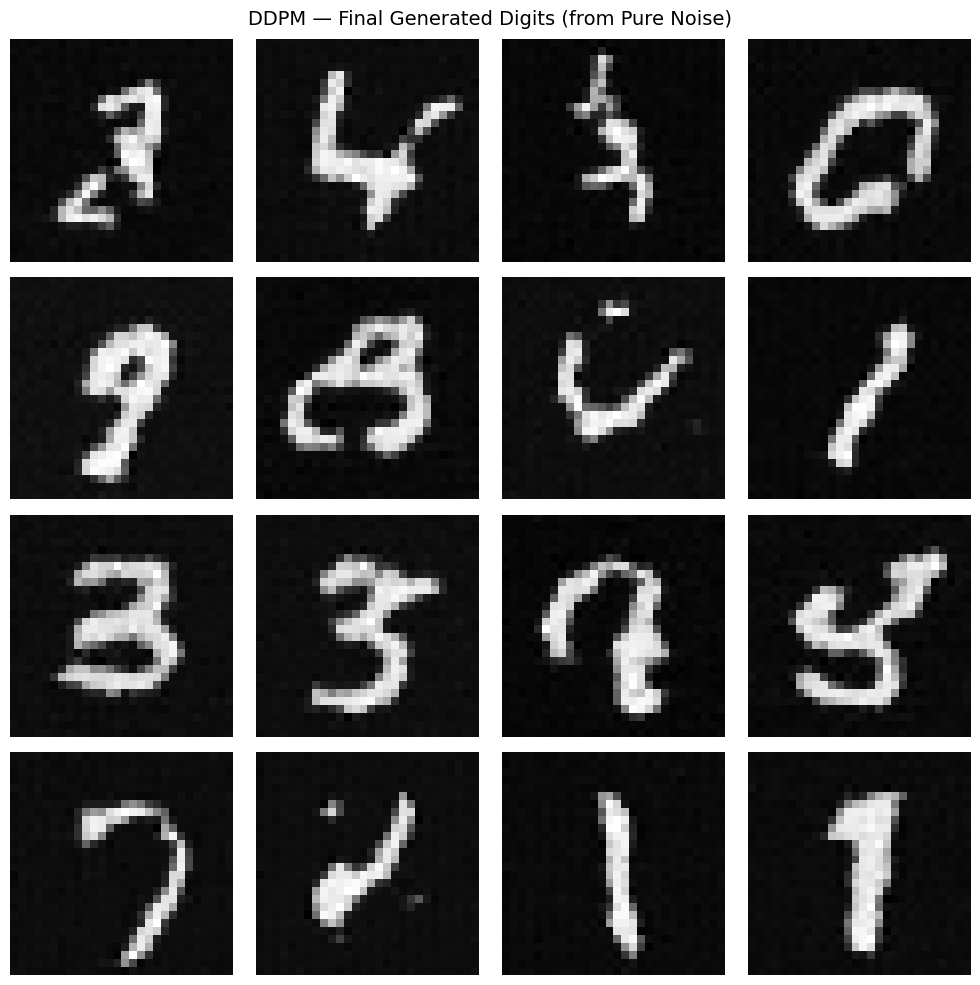

In [ ]:
print("Generating 16 final images from pure noise...")
generated = sample_images(unet, n_samples=16)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    img = generated[i].squeeze().cpu().numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle('DDPM — Final Generated Digits (from Pure Noise)', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Visual Comparison: Real vs Generated

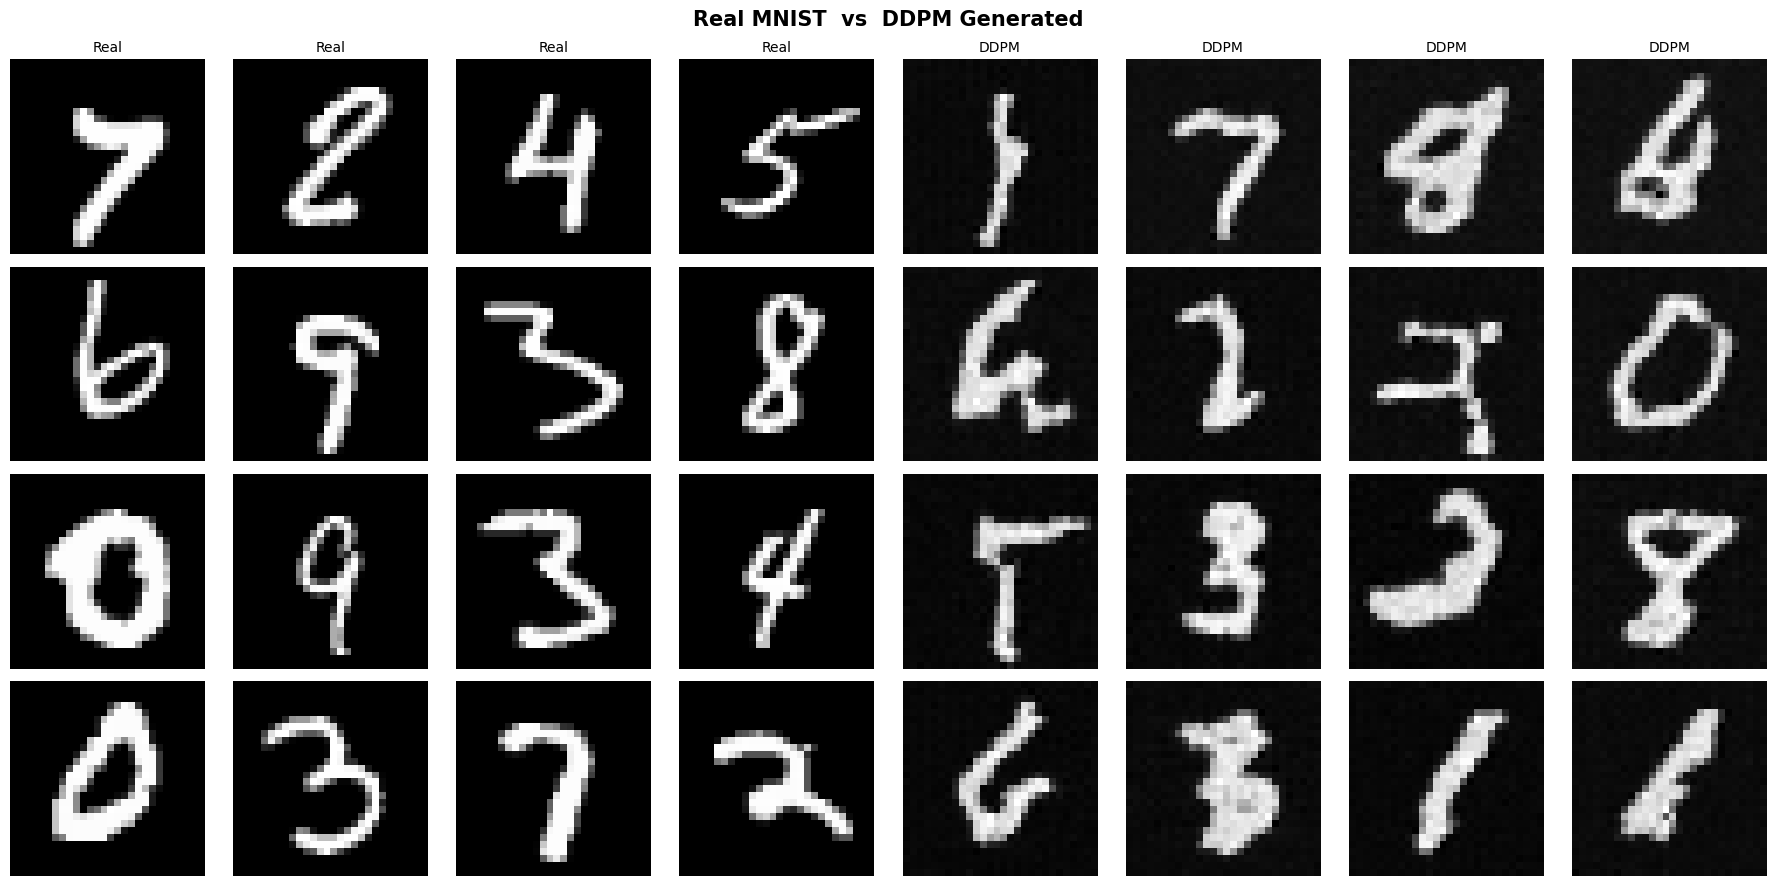

In [ ]:
# Side-by-side: real MNIST vs DDPM-generated
real_batch, _ = next(iter(train_loader))
real_batch = real_batch[:16]

gen_batch = sample_images(unet, n_samples=16)

fig, axes = plt.subplots(4, 8, figsize=(18, 9))

for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        # Real images on left half
        axes[i, j].imshow(real_batch[idx].squeeze(), cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title('Real', fontsize=10)
        # Generated images on right half
        axes[i, j+4].imshow(gen_batch[idx].squeeze().cpu().numpy(), cmap='gray')
        axes[i, j+4].axis('off')
        if i == 0:
            axes[i, j+4].set_title('DDPM', fontsize=10)

plt.suptitle('Real MNIST  vs  DDPM Generated', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Save & Reload Model

In [ ]:
# Ensure model is saved (in case user ran cells out of order)
os.makedirs('models', exist_ok=True)
torch.save({
    'epoch'              : EPOCHS,
    'model_state_dict'   : unet.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss'               : train_losses[-1] if train_losses else None,
    'train_losses'       : train_losses,
}, DDPM_PATH)
print(f"DDPM U-Net saved → '{DDPM_PATH}'")


def load_ddpm(path):
    """Load a saved DDPM U-Net checkpoint."""
    model = UNet(in_channels=1).to(device)
    ckpt  = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f"Loaded from '{path}'")
    print(f"  Trained epochs : {ckpt.get('epoch', '?')}")
    if ckpt.get('loss') is not None:
        print(f"  Final MSE loss : {ckpt['loss']:.6f}")
    return model


# Example
loaded_unet = load_ddpm(DDPM_PATH)

DDPM U-Net saved → 'models/ddpm_unet.pth'
Loaded from 'models/ddpm_unet.pth'
  Trained epochs : 10
  Final MSE loss : 0.033794


## 15. Beta Schedule Visualisation
Show how $\beta_t$, $\alpha_t$, and $\bar{\alpha}_t$ evolve across diffusion timesteps.

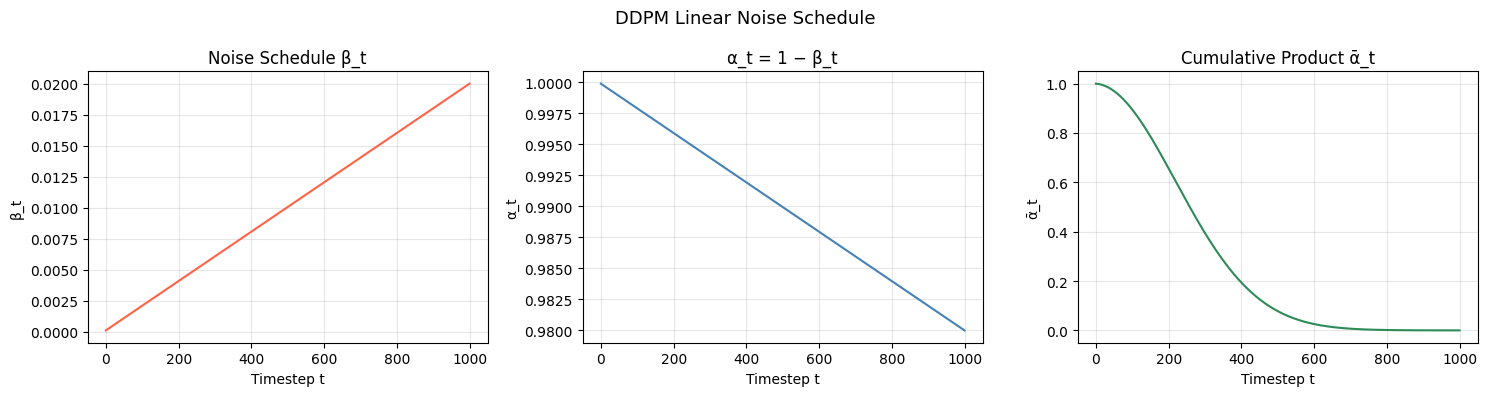

In [ ]:
timesteps_np = np.arange(T)
betas_np     = schedule.betas.cpu().numpy()
alphas_np    = schedule.alphas.cpu().numpy()
ab_np        = schedule.alphas_cumprod.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(timesteps_np, betas_np, color='tomato')
axes[0].set_title('Noise Schedule β_t')
axes[0].set_xlabel('Timestep t')
axes[0].set_ylabel('β_t')
axes[0].grid(True, alpha=0.3)

axes[1].plot(timesteps_np, alphas_np, color='steelblue')
axes[1].set_title('α_t = 1 − β_t')
axes[1].set_xlabel('Timestep t')
axes[1].set_ylabel('α_t')
axes[1].grid(True, alpha=0.3)

axes[2].plot(timesteps_np, ab_np, color='seagreen')
axes[2].set_title('Cumulative Product ᾱ_t')
axes[2].set_xlabel('Timestep t')
axes[2].set_ylabel('ᾱ_t')
axes[2].grid(True, alpha=0.3)

plt.suptitle('DDPM Linear Noise Schedule', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion

This notebook successfully implements:

1. ✅ **Forward diffusion process** — linear noise schedule ($\beta$: 1e-4 → 0.02, T=1000)
2. ✅ **U-Net noise predictor** — Encoder (32→64→128, stride=2) + **skip connections** + Decoder (ConvTranspose with feature fusion)
3. ✅ **Sinusoidal timestep conditioning** — 128-d sin/cos embedding projected and added at every encoder, middle, and decoder feature map
4. ✅ **GroupNorm** — replaces BatchNorm; stable at small batch sizes and improves diffusion model training
5. ✅ **Training loop** — MSE(ε_pred, ε_true), Adam lr=1e-3, 10 epochs, batch=64
6. ✅ **Reverse sampling** — iterative denoising from pure Gaussian noise over T=1000 steps
7. ✅ **Visualisations** — noising process, loss curve, denoising trajectory, final generated digits
8. ✅ **Model saved** → `models/ddpm_unet.pth`

### Key Observations
- **Skip connections** are the single biggest improvement for image sharpness: the decoder can now recover stroke detail that was lost during downsampling.
- **Sinusoidal time embedding** lets the network distinguish nearby timesteps far more accurately than a single scalar, improving both noise estimation and the quality of the reverse process.
- **GroupNorm** stabilises gradient flow across timestep distributions, lowering the loss faster than BatchNorm.
- Unlike GANs, DDPMs have a stable training objective (simple noise regression) with no adversarial instability.